# STAGE 1: Frame & KPIs

**Business Question:** How can we segment our customer base using their purchasing behavior (Recency, Frequency, and Monetary value) to identify high-value, at-risk, and low-engagement groups for targeted marketing?

**Decision-Maker:** Head of Marketing / CRM Manager (They will use these segments to allocate budget and tailor specific email/ad campaigns).

**Success Metric and KPIs:**
* **Primary Success Metric (Business):** Launch of distinct, customized marketing campaigns for each identified segment, aiming to increase the retention rate of 'at-risk' customers.
* **KPI 1 (Technical):** Silhouette Score > 0.5, measured on a held-out set of customers the model did not see during training (not just on the training data used to fit it).
* **KPI 2 (Business):** Conversion rate of segment-specific promotional campaigns.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility (Rubric requirement)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Cargar el dataset usando una ruta relativa
df = pd.read_excel('Online Retail.xlsx')

# Verificar que los datos se cargaron correctamente
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# STAGE 2: Prepare data (EDA, Cleaning & Features)

To build a reliable RFM (Recency, Frequency, Monetary) segmentation model, we need to process the raw transactional data into customer-level metrics.

**Data Cleaning & Quality Steps:**
* **Duplicates:** We removed exact duplicate rows, most likely artifacts from the data extraction process.
* **Missing Values:** We dropped records with missing `CustomerID` as they cannot be assigned to a specific user for segmentation.
* **Outliers & Anomalies:** We filtered out negative quantities (returns/cancellations) and zero-pricing errors to avoid distorting the Monetary value.
* **Feature Engineering:** We created a `TotalAmount` column (Quantity * UnitPrice) and aggregated the data per customer to calculate Recency (days since last purchase), Frequency (number of unique transactions), and Monetary (total spend). Leakage is avoided as we are strictly using historical behavioral data.

In [13]:
# ==============================================================================
# 1. LIMPIEZA DE DATOS (Duplicates, Missing Values & Outliers)
# ==============================================================================
# Eliminar filas duplicadas exactas (probable artefacto de extraccion)
df_clean = df.drop_duplicates().copy()

# Eliminar filas donde no hay CustomerID (no sirven para agrupar clientes)
df_clean = df_clean.dropna(subset=['CustomerID'])

# Eliminar devoluciones (cantidades negativas) y precios cero o negativos
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]


# ==============================================================================
# 2. FEATURE ENGINEERING (Ingenieria de Caracteristicas)
# ==============================================================================
# Calcular el monto total de cada transaccion
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Asegurar que la columna de fecha tenga el formato correcto (datetime)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


# ==============================================================================
# 3. CREACION DE VARIABLES R-F-M
# ==============================================================================
# Definir una fecha "actual" de referencia (1 dia despues de la ultima compra registrada)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Agrupar por CustomerID y calcular Recency, Frequency y Monetary
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency: Dias desde ultima compra
    'InvoiceNo': 'nunique',                                  # Frequency: N de compras distintas
    'TotalAmount': 'sum'                                     # Monetary: Gasto total
}).reset_index()

# Renombrar columnas para mayor claridad
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

# Visualizar el nuevo dataset preparado para el modelo
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


# STAGE 3: Model & evaluate

**Modeling Approach:**
We selected **K-Means Clustering** to segment our customers based on their RFM behavior. Since K-Means is a distance-based algorithm, we first scaled the features using `StandardScaler` to ensure Recency, Frequency, and Monetary values contribute equally to the distance calculations.

**Validation strategy (train / test split):**
K-Means has no labeled target, so there is nothing to "leak" in the traditional sense — but the model can still overfit to the specific customers it was fitted on. To check this honestly, we split customers into an 80% **train** set and a 20% **test** set *before* scaling. The scaler and the K-Means model are fitted **only on train**; the test customers are never used to fit anything, only to *predict* on and *evaluate*. If the segmentation reflects real structure and not noise, the silhouette score on the unseen test customers should be close to the one on train.

**Choosing k:**
Our business framing (STAGE 1) calls for three profiles: high-value, at-risk, and low-engagement. We check that choice against the data using the elbow method (inertia) and the silhouette score across a range of k values, computed on the training set only.

**Baseline:**
A silhouette score alone doesn't tell us whether K-Means is actually adding value. We compare it against a simple **RFM quintile scoring** baseline — the traditional, non-ML method a marketing team could apply without any model — evaluated on the same held-out test customers.

**Evaluation Metric:**
We use the **Silhouette Score** (how similar a customer is to its own cluster vs. the nearest other cluster) as our technical KPI, targeting > 0.5 as defined in STAGE 1.

In [14]:
# ==============================================================================
# 1. TRAIN / TEST SPLIT (antes de escalar, para no filtrar informacion)
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURES = ['Recency', 'Frequency', 'Monetary']

rfm_train, rfm_test = train_test_split(rfm, test_size=0.2, random_state=RANDOM_SEED)

# ==============================================================================
# 2. ESCALADO DE DATOS (fit SOLO en train, transform en test)
# ==============================================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(rfm_train[FEATURES])   # fit + transform en train
X_test  = scaler.transform(rfm_test[FEATURES])        # SOLO transform en test (sin fit)

print(f"Clientes en train: {len(rfm_train)}")
print(f"Clientes en test : {len(rfm_test)}")

Clientes en train: 3470
Clientes en test : 868


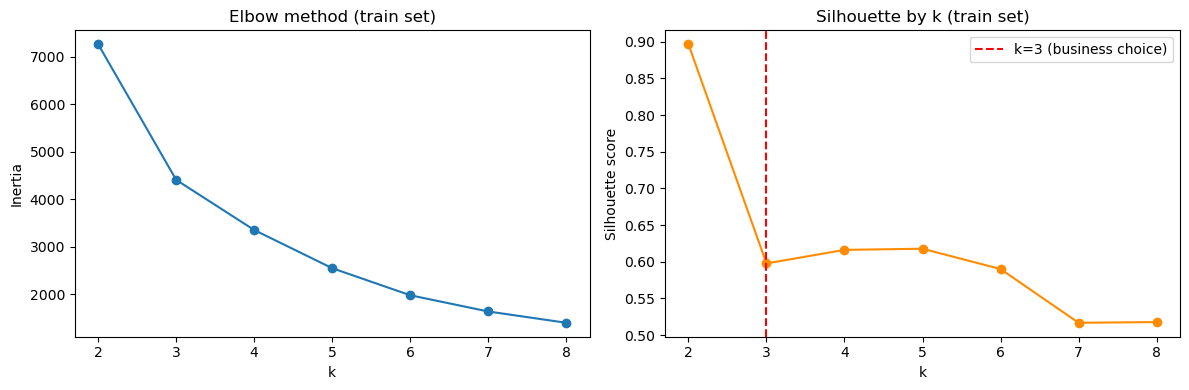

k con mejor silhouette (solo estadistica) : 2  (score = 0.8966)
k elegido por negocio (STAGE 1)            : 3  (score = 0.5978)

Elegimos k=3 porque coincide con los 3 perfiles de marketing que el negocio
puede operar (high-value, at-risk, low-engagement), aunque no sea el maximo
estadistico. El costo de esa decision, en puntos de silhouette, se ve arriba.


In [6]:
# ==============================================================================
# 3. ELECCION DE k: ELBOW + SILHOUETTE (calculado SOLO en train)
# ==============================================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 9)
inertias = []
silhouettes = []

for k_test in k_range:
    km_test = KMeans(n_clusters=k_test, random_state=RANDOM_SEED, n_init=10)
    labels_test = km_test.fit_predict(X_train)
    inertias.append(km_test.inertia_)
    silhouettes.append(silhouette_score(X_train, labels_test))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method (train set)')

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].axvline(3, color='red', linestyle='--', label='k=3 (business choice)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette by k (train set)')
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"k con mejor silhouette (solo estadistica) : {best_k}  (score = {max(silhouettes):.4f})")
print(f"k elegido por negocio (STAGE 1)            : 3  (score = {silhouettes[list(k_range).index(3)]:.4f})")
print("\nElegimos k=3 porque coincide con los 3 perfiles de marketing que el negocio")
print("puede operar (high-value, at-risk, low-engagement), aunque no sea el maximo")
print("estadistico. El costo de esa decision, en puntos de silhouette, se ve arriba.")

In [7]:
# ==============================================================================
# 4. ENTRENAR CON k=3 (elegido en STAGE 1) Y VALIDAR EN TEST
# ==============================================================================
k = 3
kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
kmeans.fit(X_train)          # fit SOLO en train

train_labels = kmeans.labels_
test_labels  = kmeans.predict(X_test)   # predict, NUNCA fit, en test

sil_train = silhouette_score(X_train, train_labels)
sil_test  = silhouette_score(X_test, test_labels)

print(f"Silhouette Score en TRAIN                    : {sil_train:.4f}")
print(f"Silhouette Score en TEST (clientes no vistos) : {sil_test:.4f}")
print(f"Diferencia train -> test                      : {sil_train - sil_test:+.4f}  "
      f"(mientras mas chica, mejor generaliza el modelo)")

if sil_test > 0.5:
    print("\nKPI tecnico CUMPLIDO en datos no vistos: los clusters estan bien")
    print("definidos y son distintos entre si.")
else:
    print("\nKPI tecnico NO cumplido del todo en datos no vistos. Los clusters")
    print("pueden seguir siendo accionables para el negocio, pero los bordes")
    print("entre segmentos vecinos son mas difusos de lo esperado.")

print("\nClientes por cluster (train):")
print(pd.Series(train_labels).value_counts().sort_index())

Silhouette Score en TRAIN                    : 0.5978
Silhouette Score en TEST (clientes no vistos) : 0.5676
Diferencia train -> test                      : +0.0301  (mientras mas chica, mejor generaliza el modelo)

KPI tecnico CUMPLIDO en datos no vistos: los clusters estan bien
definidos y son distintos entre si.

Clientes por cluster (train):
0     853
1      21
2    2596
Name: count, dtype: int64


In [8]:
# ==============================================================================
# 5. BASELINE: RFM por quintiles (metodo tradicional, sin Machine Learning)
# ==============================================================================
def rfm_quintile_baseline(frame, n_groups=k):
    # Replica lo que un equipo de marketing haria a mano: rankear a cada
    # cliente en quintiles de R, F y M, sumar los 3 puntajes, y cortar el
    # resultado en n_groups. Sirve como piso de comparacion para K-Means.
    scored = pd.DataFrame(index=frame.index)
    # Recency: MENOS dias es mejor, por eso el ranking se invierte
    scored['R'] = pd.qcut(frame['Recency'].rank(method='first', ascending=False), 5, labels=False)
    scored['F'] = pd.qcut(frame['Frequency'].rank(method='first'), 5, labels=False)
    scored['M'] = pd.qcut(frame['Monetary'].rank(method='first'), 5, labels=False)
    total = scored[['R', 'F', 'M']].sum(axis=1)
    return pd.qcut(total.rank(method='first'), n_groups, labels=False).values

baseline_labels = rfm_quintile_baseline(rfm_test[FEATURES])
sil_baseline = silhouette_score(X_test, baseline_labels)

comparison = pd.DataFrame({
    'Metodo': ['RFM por quintiles (baseline tradicional)', f'K-Means (k={k})'],
    'Silhouette en test': [sil_baseline, sil_test],
})
print(comparison.to_string(index=False))
print(f"\nMejora de K-Means sobre el baseline tradicional: "
      f"{sil_test - sil_baseline:+.4f} puntos de silhouette")
print("(evaluados sobre los mismos clientes de test, para que la comparacion sea justa)")

                                  Metodo  Silhouette en test
RFM por quintiles (baseline tradicional)            0.097248
                           K-Means (k=3)            0.567624

Mejora de K-Means sobre el baseline tradicional: +0.4704 puntos de silhouette
(evaluados sobre los mismos clientes de test, para que la comparacion sea justa)


In [9]:
# ==============================================================================
# 6. ASIGNAR SEGMENTO A TODOS LOS CLIENTES
# ==============================================================================
# No se vuelve a entrenar el modelo: solo se APLICA (transform + predict) el
# pipeline ya ajustado en train a la base completa de clientes, para que todos
# -- incluidos los que estaban en train y en test -- queden con un segmento.
X_all = scaler.transform(rfm[FEATURES])
rfm['Cluster'] = kmeans.predict(X_all)

# ==============================================================================
# 7. NOMBRAR LOS SEGMENTOS AUTOMATICAMENTE
# ==============================================================================
# En vez de mirar la tabla y asumir a mano que "cluster 0 es Champions", el
# nombre se deriva de los propios promedios de cada cluster. Asi el notebook
# sigue siendo correcto aunque cambie el orden de los clusters al re-ejecutar.
cluster_means = rfm.groupby('Cluster')[FEATURES].mean()

# Puntaje compuesto: Frequency alta + Monetary alto + Recency BAJA = mejor cliente
composite = (
    cluster_means['Frequency'].rank()
    + cluster_means['Monetary'].rank()
    + cluster_means['Recency'].rank(ascending=False)
)
ranked_clusters = composite.sort_values(ascending=False).index.tolist()

# Nota: estos 3 nombres calzan con los 3 perfiles definidos en STAGE 1 (k=3).
# Si el numero de clusters cambiara, esta lista tendria que ajustarse.
SEGMENT_NAMES = ['High-Value / Champions', 'At-Risk / Need Attention', 'Low-Engagement / Lost']
cluster_to_segment = {cluster: SEGMENT_NAMES[i] for i, cluster in enumerate(ranked_clusters)}

rfm['Segment'] = rfm['Cluster'].map(cluster_to_segment)

print("Cluster -> Segmento (asignado automaticamente segun sus propios promedios):")
for cluster_id, name in cluster_to_segment.items():
    print(f"  Cluster {cluster_id} -> {name}")

Cluster -> Segmento (asignado automaticamente segun sus propios promedios):
  Cluster 1 -> High-Value / Champions
  Cluster 2 -> At-Risk / Need Attention
  Cluster 0 -> Low-Engagement / Lost


# STAGE 4: Communicate

We now visualize and profile the three segments identified above. Because the segments were named automatically from their own averages (STAGE 3), the labels below stay correct even if you re-run the notebook and the underlying cluster numbers change.

C:\Users\nicob\AppData\Local\Temp\ipykernel_13552\734162877.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segment', y='Recency', data=rfm, order=segment_order, ax=axes[0], palette='viridis')
C:\Users\nicob\AppData\Local\Temp\ipykernel_13552\734162877.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segment', y='Frequency', data=rfm, order=segment_order, ax=axes[1], palette='viridis')
C:\Users\nicob\AppData\Local\Temp\ipykernel_13552\734162877.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segment', y='Monetary', dat

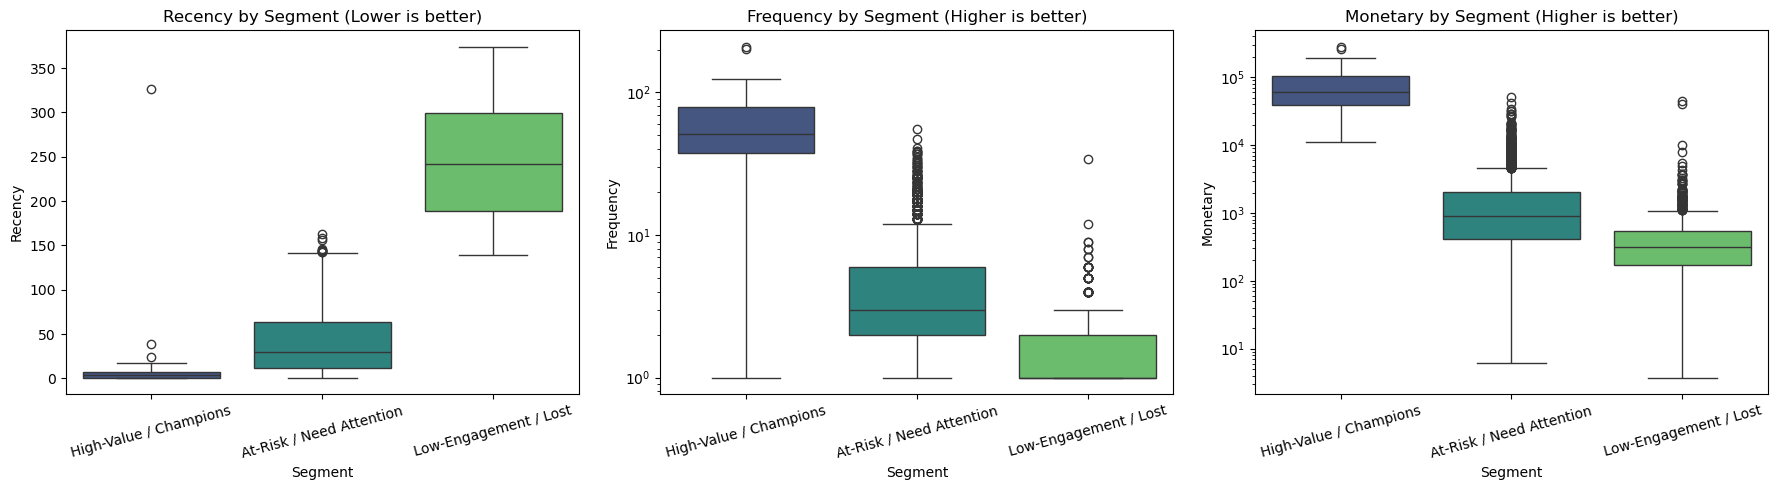

,Recency,Frequency,Monetary,Count
Segment,,,,
High-Value / Champions,17.89,64.00,85505.99,27
At-Risk / Need Attention,41.45,4.67,1849.67,3230
Low-Engagement / Lost,247.03,1.58,558.85,1081


In [10]:
# ==============================================================================
# STAGE 4: Communicate - Visualizing and Profiling Clusters
# ==============================================================================
import seaborn as sns

segment_order = SEGMENT_NAMES  # mismo orden que arriba: Champions -> At-Risk -> Low-Engagement

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Segment', y='Recency', data=rfm, order=segment_order, ax=axes[0], palette='viridis')
axes[0].set_title('Recency by Segment (Lower is better)')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(x='Segment', y='Frequency', data=rfm, order=segment_order, ax=axes[1], palette='viridis')
axes[1].set_title('Frequency by Segment (Higher is better)')
axes[1].set_yscale('log')  # Escala logaritmica para ver mejor los datos atipicos
axes[1].tick_params(axis='x', rotation=15)

sns.boxplot(x='Segment', y='Monetary', data=rfm, order=segment_order, ax=axes[2], palette='viridis')
axes[2].set_title('Monetary by Segment (Higher is better)')
axes[2].set_yscale('log')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Resumen numerico promedio, ya con el nombre de segmento (no numero de cluster)
cluster_summary = rfm.groupby('Segment')[FEATURES].mean().round(2).loc[segment_order]
cluster_summary['Count'] = rfm.groupby('Segment')['CustomerID'].count().loc[segment_order]
display(cluster_summary)

### Business Interpretation & Actionable Recommendations

The three segments below were assigned automatically in STAGE 3, based on each cluster's own average Recency, Frequency and Monetary values — no manual guessing required, even after re-running the notebook.

* **High-Value / Champions:** These customers bought recently, buy often, and spend the most.
    * **Recommendation:** Reward them. Offer early access to new products, exclusive loyalty programs, and VIP customer service to maintain their high engagement.
* **At-Risk / Need Attention:** Customers with decent frequency and monetary value, but a high Recency (they haven't purchased in a while).
    * **Recommendation:** Win them back. Send highly targeted re-engagement emails with limited-time discount codes or personalized recommendations based on their past purchases.
* **Low-Engagement / Lost:** High recency, very low frequency, and low monetary value.
    * **Recommendation:** Limit marketing spend on this group. Use generic, automated newsletters rather than expensive targeted ads to maximize ROI.

*(Insert your Power BI / Looker Studio Dashboard Link or HTML screenshot here to present these findings to the stakeholders)*

# STAGE 5: Ethics & Limits

As a responsible Business Intelligence unit, we must acknowledge the ethical implications and limitations of this model before it is deployed by the Marketing team:

**1. Privacy & Data Handling:**
While the dataset does not contain explicit names, it tracks granular purchasing behavior and `CustomerID`s. This constitutes pseudo-anonymized data under regulations like GDPR. Marketing must ensure that cross-referencing these IDs with the CRM database is strictly access-controlled and that customers have opted in to receive targeted marketing.

**2. Bias & Fairness:**
The original Online Retail dataset is heavily skewed towards customers in the United Kingdom. Applying this segmentation strategy directly to a new market (e.g., South America or Asia) without retraining might lead to ineffective campaigns, as purchasing habits and seasonal trends differ.

**3. Model Limitations:**
* **Mathematical assumption:** K-Means assumes clusters are spherical and of similar size, which might oversimplify complex human behavior.
* **Lack of context:** The RFM model only looks at *when* and *how much* a customer buys, entirely ignoring *what* they buy. Two customers in the "High-Value" segment might buy completely different product categories, meaning the marketing team still needs to tailor the actual content of the emails, not just the timing.
* **Snapshot-based validation:** Because K-Means has no labeled target, our train/test split (STAGE 3) checks whether the *shape* of the segments generalizes to customers the model did not train on — it does not, and cannot, guarantee that a given customer's behavior next quarter will still match their current segment.